In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Leitura do dataframe

In [2]:
df_recife = pd.read_csv('../dados/df_recife.csv', index_col=0)
df_recife

,Data,Hora UTC,"PRECIPITAÇÃO TOTAL, HORÁRIO (mm)","PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)",PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB),PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB),"TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)",TEMPERATURA DO PONTO DE ORVALHO (°C),TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C),TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C),TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C),TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C),UMIDADE REL. MAX. NA HORA ANT. (AUT) (%),UMIDADE REL. MIN. NA HORA ANT. (AUT) (%),"UMIDADE RELATIVA DO AR, HORARIA (%)","VENTO, DIREÇÃO HORARIA (gr) (° (gr))","VENTO, RAJADA MAXIMA (m/s)","VENTO, VELOCIDADE HORARIA (m/s)"
0,2019-01-01,0000 UTC,0,1013,1013,"1012,8",27,"22,2","27,1","26,9","22,4","22,1",76.0,75.0,75.0,114.0,"4,8","1,9"
1,2019-01-01,0100 UTC,0,"1012,8",1013,"1012,8","26,7",22,"27,1","26,6","22,2","21,9",76.0,74.0,76.0,122.0,"4,8","1,4"
2,2019-01-01,0200 UTC,0,"1012,5","1012,8","1012,5","26,6","22,1","26,8","26,5","22,2","21,9",76.0,76.0,76.0,123.0,"4,8","1,7"
3,2019-01-01,0300 UTC,0,"1011,8","1012,5","1011,8","26,3",22,"26,7","26,3","22,2",22,78.0,76.0,77.0,120.0,"4,3","1,3"
4,2019-01-01,0400 UTC,0,"1011,4","1011,8","1011,4","26,1","21,8","26,6","26,1","22,2","21,7",77.0,76.0,77.0,123.0,"4,4","1,2"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17539,2020-12-31,1900 UTC,0,"1011,3","1011,3",1011,"26,8","22,5",27,"26,2","23,8","22,3",83.0,77.0,77.0,124.0,"6,3","2,4"
17540,2020-12-31,2000 UTC,0,"1011,6","1011,7","1011,3","25,8","21,7","26,8","25,8","22,4","21,7",78.0,76.0,78.0,125.0,"6,2","2,4"
17541,2020-12-31,2100 UTC,0,"1012,1","1012,1","1011,6","26,2",22,"26,2","25,6","22,2","21,7",81.0,78.0,78.0,136.0,"5,8",2
17542,2020-12-31,2200 UTC,0,"1012,5","1012,5",1012,"26,3","21,8","26,3","26,1",22,"21,7",78.0,76.0,76.0,130.0,"5,3","1,8"


In [3]:
df_recife.columns

Index(['Data', 'Hora UTC', 'PRECIPITAÇÃO TOTAL, HORÁRIO (mm)',
       'PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)',
       'PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)',
       'PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)',
       'TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)',
       'TEMPERATURA DO PONTO DE ORVALHO (°C)',
       'TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)',
       'TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)',
       'TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C)',
       'TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C)',
       'UMIDADE REL. MAX. NA HORA ANT. (AUT) (%)',
       'UMIDADE REL. MIN. NA HORA ANT. (AUT) (%)',
       'UMIDADE RELATIVA DO AR, HORARIA (%)',
       'VENTO, DIREÇÃO HORARIA (gr) (° (gr))', 'VENTO, RAJADA MAXIMA (m/s)',
       'VENTO, VELOCIDADE HORARIA (m/s)'],
      dtype='str')

Ajeitar tipo das colunas

In [4]:
df_recife["Hora UTC"] = (
    df_recife["Hora UTC"]
    .str.replace(" UTC", "", regex=False)
    .str.zfill(4)
)

df_recife["Hora UTC"] = pd.to_datetime(
    df_recife["Hora UTC"],
    format="%H%M"
).dt.time

In [5]:
df_recife["datetime"] = pd.to_datetime(
    df_recife["Data"].astype(str) + " " + df_recife["Hora UTC"].astype(str),
    errors="coerce"
)

df_recife = df_recife.sort_values("datetime").reset_index(drop=True)

In [6]:
df_recife["PRECIPITAÇÃO TOTAL, HORÁRIO (mm)"] = pd.to_numeric(
    df_recife["PRECIPITAÇÃO TOTAL, HORÁRIO (mm)"],
    errors="coerce"
)

df_recife["PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)"] = pd.to_numeric(
    df_recife["PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)"],
    errors="coerce"
)

df_recife["TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)"] = pd.to_numeric(
    df_recife["TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)"],
    errors="coerce"
)

df_recife["UMIDADE RELATIVA DO AR, HORARIA (%)"] = pd.to_numeric(
    df_recife["UMIDADE RELATIVA DO AR, HORARIA (%)"],
    errors="coerce"
)

df_recife["VENTO, VELOCIDADE HORARIA (m/s)"] = pd.to_numeric(
    df_recife["VENTO, VELOCIDADE HORARIA (m/s)"],
    errors="coerce"
)

Preparação das colunas e tratamento de nulos por interpolação

In [7]:
coluna_precipitacao = "PRECIPITAÇÃO TOTAL, HORÁRIO (mm)"

variaveis = {
    "Pressão": "PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)",
    "Temperatura": "TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)",
    "Umidade": "UMIDADE RELATIVA DO AR, HORARIA (%)",
    "Vento": "VENTO, VELOCIDADE HORARIA (m/s)"
}

In [8]:
df_recife = (
    df_recife
    .sort_values("datetime")
    .reset_index(drop=True)
)

In [9]:
colunas_meteorologicas = list(variaveis.values())

for coluna in colunas_meteorologicas:

    df_recife[coluna] = (
        df_recife[coluna]
        .interpolate(
            method="linear",
            limit_direction="both"
        )
    )

    df_recife[coluna] = (
        df_recife[coluna]
        .ffill()
        .bfill()
    )


Separação de chuvas fortes

In [10]:
chuva_forte = (
    df_recife[coluna_precipitacao] >= 10
)

inicio_chuva = (
    chuva_forte &
    ~chuva_forte.shift(1, fill_value=False)
)

eventos = df_recife.index[inicio_chuva].tolist()

print("Total de eventos de chuva forte:", len(eventos))

Total de eventos de chuva forte: 8


Análise do período prévio à chuva

In [11]:
resultados = []

for evento in eventos:

    if evento < 6:
        continue

    grupo = df_recife.iloc[
        evento - 6:evento
    ].copy()

    grupo["horas_antes"] = np.arange(-6, 0)

    for nome, coluna in variaveis.items():

        media_6h = grupo[coluna].mean()

        if pd.isna(media_6h) or abs(media_6h) < 0.000001:

            grupo[nome] = np.nan

        else:

            grupo[nome] = (
                (grupo[coluna] - media_6h)
                / abs(media_6h)
            ) * 100

    resultados.append(
        grupo[
            ["horas_antes"] +
            list(variaveis.keys())
        ]
    )

In [12]:
resultado_final = pd.concat(
    resultados,
    ignore_index=True
)

Média de eventos por hora

In [13]:
media_desvios = (
    resultado_final
    .groupby("horas_antes")
    [list(variaveis.keys())]
    .mean()
    .reset_index()
)

Plot do gráfico

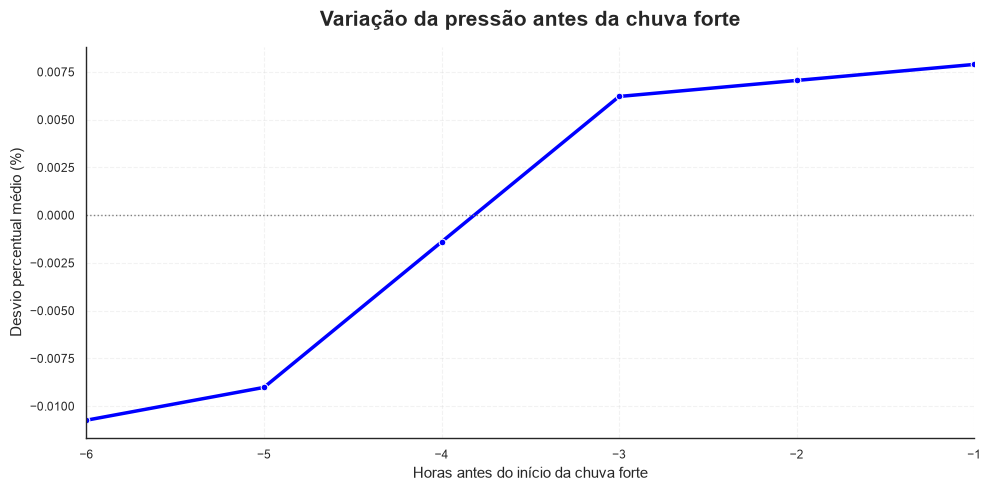

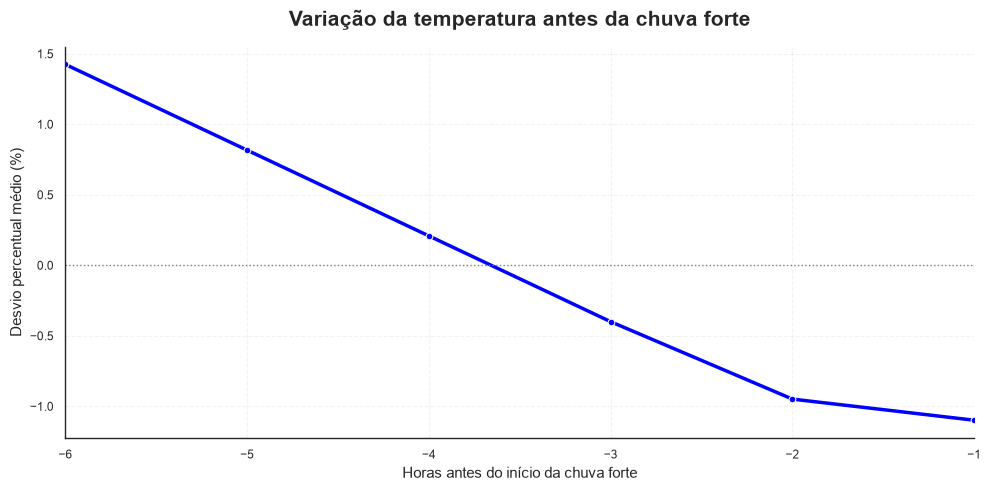

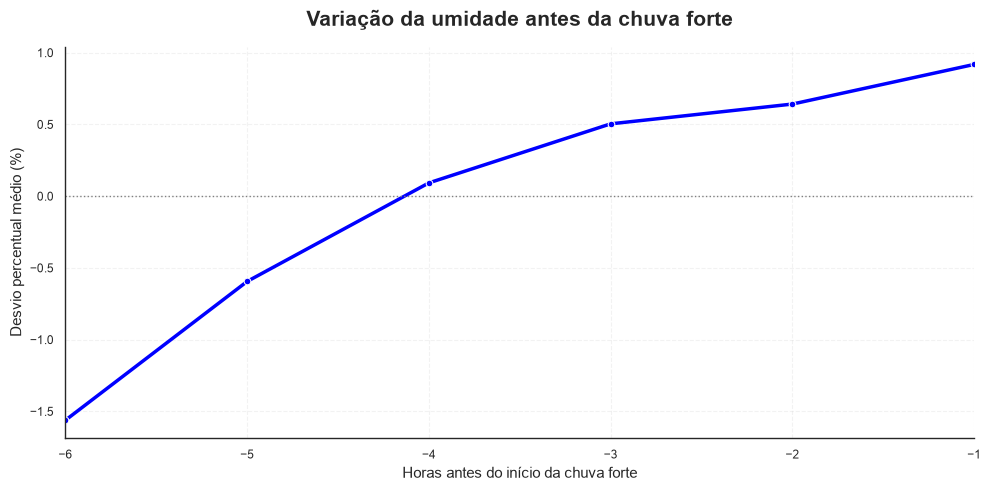

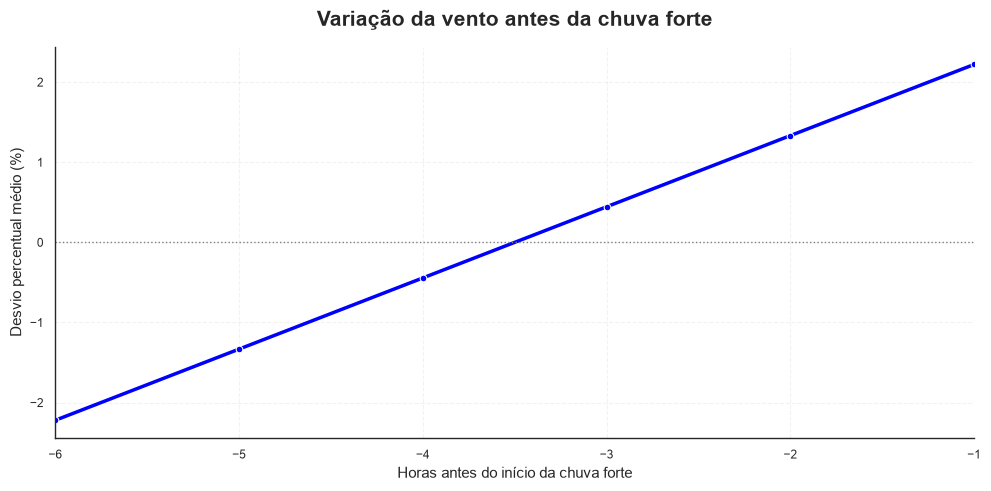

In [14]:
sns.set_theme(
    style="white",
    context="paper"
)

for nome in variaveis.keys():

    fig, ax = plt.subplots(
        figsize=(10, 5),
        facecolor="white"
    )

    ax.set_facecolor("white")

    sns.lineplot(
        data=media_desvios,
        x="horas_antes",
        y=nome,
        marker="o",
        linewidth=2.5,
        color="blue",
        ax=ax
    )

    ax.axvline(
        x=0,
        color="black",
        linestyle="--",
        linewidth=1.5
    )

    ax.axhline(
        y=0,
        color="gray",
        linestyle=":",
        linewidth=1
    )

    ax.set_title(
        f"Variação da {nome.lower()} antes da chuva forte",
        fontsize=15,
        fontweight="bold",
        pad=15
    )

    ax.set_xlabel(
        "Horas antes do início da chuva forte",
        fontsize=11
    )

    ax.set_ylabel(
        "Desvio percentual médio (%)",
        fontsize=11
    )

    ax.set_xticks(
        np.arange(-6, 0, 1)
    )

    ax.set_xlim(-6, -1)

    ax.grid(
        True,
        linestyle="--",
        alpha=0.25
    )

    sns.despine(
        ax=ax,
        top=True,
        right=True
    )

    plt.tight_layout()

    plt.show()